# Verifica se un albero binario è di ricerca

In [2]:
from typing import override

from alberi.alberibinari import AlberoBin

class abr(AlberoBin):
    def diRicerca(self):
        return abr._diRicercaRic(self, float('-inf'), float('inf'))
    @staticmethod
    def _diRicercaRic(nodo, min:int, max:int):
        if nodo is None:
            return True
        if nodo.val <= min or nodo.val >= max:
            return False
        return abr._diRicercaRic(nodo.sin, min, nodo.val) and abr._diRicercaRic(nodo.des.val, max)

# Dato un albero binario verificare se è bilanciato
con un algoritmo ricorsivo di complessità lineare

In [3]:
class abb(AlberoBin):
    def is_bilanciato(self):
        return abb._is_bilanciato(self)[1]
    @staticmethod
    def _is_bilanciato(nodo:AlberoBin) -> tuple[int, bool]:
        if nodo is None:
            return (0, True)
        resSin = abb._is_bilanciato(nodo.sin)
        resDes = abb._is_bilanciato(nodo.des)
        if (not resDes[1] or not resSin[1]):
            return (0, False)
        return (max(resSin[0], resDes[0])+1, abs(resSin[0] - resDes[0]) <= 1)

    # versione incredibilmente pulita
    def is_bilanciato2(self):
        try:
            abb._is_bilanciato2(self)
            return True
        except ValueError:
            return False
    @staticmethod
    def _is_bilanciato2(nodo:AlberoBin) -> int:
        if nodo is None:
            return 0
        hSin = abb._is_bilanciato2(nodo.sin)
        hDes = abb._is_bilanciato2(nodo.des)
        if abs(hSin-hDes) > 1:
            raise ValueError("non bilanciato")
        return max(hSin, hDes) + 1

# Visita sui grafi

In [4]:
from grafi.grafi import GrafoMA
from grafi.grafi import GrafoLA
from grafi.grafino import GrafoLANO
from grafi.grafino import GrafoMANO

class Visita(GrafoLA):
    def _visita_prof(self, nodo: int, visitati: list[bool], res: list[int]):
        if not visitati[nodo]:
            visitati[nodo] = True
            res.append(nodo)
            for a in self.adiacenti(nodo):
                self._visita_prof(a, visitati, res)
    def visita_prof(self, nodo: int) -> list[int]:
        res: list[int] = []
        visitati: list[bool] = [False for _ in range(self.n)]
        self._visita_prof(nodo, visitati, res)
        return res

    def visita_vent(self, nodo:int) -> list[int]:
        res: list[int] = [nodo]
        visitati: list[bool] = [False for _ in range(self.n)]
        coda: list[int] = [nodo]
        visitati[nodo] = True
        while(coda):
            curr: int = coda.pop(0)
            for a in self.adiacenti(curr):
                if not visitati[a]:
                    visitati[a] = True
                    coda.append(a)
                    res.append(a)
        return res

# Verifica se un grafo è un albero / verifica aciclicità

In [5]:
from grafi.grafi import GrafoMA
from grafi.grafi import GrafoLA
from grafi.grafino import GrafoLANO
from grafi.grafino import GrafoMANO

class GrafoAlberoOR(Visita):
    def verificaAlberoOR(self):
        return self.n == self.m + 1 and self.econnessoOR(0)
    def econnessoOR(self, nodo: int) -> bool:
        visita = self.visita_vent(nodo)
        if len(visita) == self.n:
            return True
        return False
    def eaciclicoOR(self):
        visitati: list[bool] = [False for _ in range(self.n)]
        k: int = 0
        for i in range(self.n):
            if not visitati[i]:
                k += 1
                self._visita_prof(i, visitati, [])
        return self.n < self.m + k

class GrafoAlberoNO(GrafoLANO):
    def aciclicoNO(self):
        rimossi: list[bool] = [False for _ in range(self.n)]
        gradi: list[int] = [0 for _ in range(self.n)]
        for a in self.archi():
            gradi[a[1]] += 1
        curr = self.trovaZero(gradi, rimossi)
        while curr != -1:
            rimossi[curr] = True
            for a in self.adiacenti(curr):
                gradi[a] -= 1
            curr = self.trovaZero(gradi, rimossi)
        return self.tuttiZeri(gradi)
    def tuttiZeri(self, gradi: list[int]):
        for i in gradi:
            if i != 0:
                return False
        return True
    def trovaZero(self, gradi: list[int], rimossi: list[bool]):
        for i in range(len(gradi)):
            if gradi[i] == 0 and not rimossi[i]:
                return i
        return -1

# Scheduling delle attività
Caso pratico di utilizzo di un grafo aciclico orientato (DAG).

- Ogni nodo del grafo rappresenta un'attività da svolgere.
- Ogni arco rappresenta una relazione di propedeuticità tra due attività (es. A→B significa "A deve terminare prima che B possa iniziare").
- Ogni attività ha un proprio tempo di esecuzione.
- Hai a disposizione un numero illimitato di esecutori (quindi più attività possono partire in parallelo, appena le loro propedeuticità sono soddisfatte).
- Si parte al tempo 0.

Domanda: qual è il tempo minimo necessario per completare tutte le attività, rispettando i vincoli di propedeuticità?

In [6]:
class Scheduler(GrafoAlberoOR):
    def scheduling(self) -> int:
        t: int = 0
        visitati: list[bool] = [False for _ in range(self.n)]
        gradi: list[int] = [0 for _ in range(self.n)]
        for p, a in self.archi():
            gradi[a] += 1
        esec: list[tuple[int, int]] = []
        esec.extend(self.trovazeri(gradi, visitati))
        while esec:
            curr = min(esec, key = lambda x: x[1])
            esec.remove(curr)
            t += curr[1]
            for i in range(len(esec)):
                esec[i] = (esec[i][0], esec[i][1] - curr[1])
            for a in self.adiacenti(curr[0]):
                gradi[a] -= 1
            esec.extend(self.trovazeri(gradi, visitati))
        return t

    # trova tutti quelli che hanno grado di ingresso 0, li aggiunge a una lista associandoci il tempo rimanente alla fine dell'esecuzione e li restituisce
    def trovazeri(self, gradi: list[int], visitati: list[bool]) -> list[tuple[int, int]]:
        res: list[tuple[int, int]] = []
        for i in range(len(gradi)):
            if gradi[i] == 0 and not visitati[i]:
                visitati[i] = True
                res.append((i,i))
        return res

In [7]:
from grafi.grafi import GrafoLA
from grafi.grafi import GrafoMA

# Scheduler, Visita e GrafoAlberoOR li presumo già definiti in celle precedenti del notebook


def costruisci_dag() -> Scheduler:
    # 5 nodi, indice == durata (nodo 0 dura 0, nodo 3 dura 3, ecc.)
    g = Scheduler(5)
    g.aggiungiarco(0, 1)
    g.aggiungiarco(0, 2)
    g.aggiungiarco(1, 3)
    g.aggiungiarco(2, 3)
    g.aggiungiarco(3, 4)
    return g


def main():
    g = costruisci_dag()

    # Cammino critico atteso: 0 -> 2 -> 3 -> 4 = durate 0+2+3+4 = 9
    # (l'altro ramo 0 -> 1 -> 3 -> 4 = 0+1+3+4 = 8, quindi non è quello critico)
    atteso = 9
    risultato = g.scheduling()

    print(f"Tempo minimo calcolato: {risultato}")
    print(f"Atteso: {atteso}")
    assert risultato == atteso, f"FALLITO: atteso {atteso}, ottenuto {risultato}"
    print("Test superato.")


if __name__ == "__main__":
    main()

Tempo minimo calcolato: 9
Atteso: 9
Test superato.


# Esercizio
>[!quote] Esercizio
>Sui grafi tipicamente non orientati con costi di percorrenza un problema è l'analisi del grafo in particolare uno degli obbiettivi è quello di identificare nodi cruciali (nel mantenere la connettività del grafo)
>una di queste misure è la **centralità** del nodo (numero di cammini minimi tra coppie di valori del grafo che lo ha come nodo intermedio)
>se killo un nodo molto centrale rendo più difficile attraversare il grafo
>applicazione militare: devo decidere cosa bombardare
>applicazione civile: per le epidemie chiudo gli snodi di spostamento rallentando il propagarsi
>modificando Floyd, mantenendo la cazzo della matrice✨ `D[i,j,k]` anche tutti i cammini minimi (sono un numero esponenziale), la complessità farà schifo comunque.

Dato un grafo non orientato pesato (pesi = costo di percorrenza), calcolare la centralità di ogni nodo, definita come il numero di cammini minimi (tra tutte le coppie di nodi) che passano per quel nodo come nodo intermedio.

L'idea è identificare i nodi "cruciali" per la connettività del grafo: rimuovendo un nodo ad alta centralità, il grafo diventa più difficile da attraversare (applicazioni: interdizione militare di uno snodo, chiusura di un nodo per rallentare un contagio).

Richiesta: modificare l'algoritmo di Floyd-Warshall in modo da, oltre alle distanze minime, tenere traccia anche del numero di cammini minimi che passano per ciascun nodo intermedio, tenendo conto che possono essercene più di uno (potenzialmente esponenziali) per coppia.

In [ ]:
def centralita(g: grafoP):
    M = [[sys.maxsize for i in range(g.n)] for j in range(g.n)]  # Calcola matrice di adiacenza
    for i in range(g.n):
        M[i][i] = 0 # aggiungo il primo passo: diagonale pari a 0
    for x, y, p in g.archi():
        M[x][y] = p
    for x in range(len(M)):
        for u in range(len(M)):
            for v in range(len(M)):
                if M[u][v] > M[u][x] + M[x][v]:
                    M[u][v] = M[u][x] + M[x][v]
    c: list[int] = [0 for _ in range(g.n)]
    for i in range(g.n):
        for j in range(g.n):
            for k in range(g.n):
                if k != i and k != j and M[i][j] == M[i][k] + M[k][j]:
                    c[k] += 1
    return M, c

# Distanza minima tra due stringhe

In [ ]:
def distanza(s1: str, s2: str) -> int:
    D = [[0 for _ in range(len(s2) + 1)] for _ in range(len(s1) + 1)]
    for i in range(len(s1) + 1):
        for j in range(len(s2) + 1):
            if i == 0:
                D[i][j] = j
            elif j == 0:
                D[i][j] = i
            else:
                D[i][j] = min(D[i-1][j] + 1, D[i][j-1] + 1, D[i-1][j-1] + (0 if s1[i-1] == s2[j-1] else 1))
    return D[len(s1)][len(s2)]

# N regine

In [2]:
from backtracking.backtracking import ProblemaBack

class Nregine(ProblemaBack):
    N = 9
    pos: list[int] = [-1 for _ in range(N)] # i indice di riga, pos[i] indice di colonna


    def primaScelta(self, liv: int):
        self.pos[liv] = 0
        return True

    def successivaScelta(self, liv: int)->bool:
        if self.pos[liv] >= self.N-1:
            return False
        self.pos[liv] += 1
        return True

    def solCompleta(self, liv: int)->bool:
        for i in range(self.N):
            if self.pos[i] == -1:
                return False
        return True

    def verificaVincoli(self, liv: int)->bool:
        for i in range(liv):
            if self.pos[i] == self.pos[liv] or abs(self.pos[i] - self.pos[liv]) == abs(i-liv):
                return False
        return True

    def costruisciSoluzione(self, liv: int):
        sol: list[list[int]] = [[0 for _ in range(self.N)] for _ in range(self.N)]
        for i in self.pos:
            sol[i][self.pos[i]] = 1
        for i in range(self.N):
            for j in range(self.N):
                print(sol[i][j], end="")
            print()

def main():
    r = Nregine().risolvi()

if __name__ == "__main__":
    main()

100000000
001000000
000001000
000000010
010000000
000100000
000000001
000000100
000010000


# Grafo colorato

Dato un grafo non orientato, e un intero k, scrivere un algoritmo che determini se è possibile colorare i vertici di G usando al più k colori, in modo tale che due vertici adiacenti non abbiano mai lo stesso colore.

In [ ]:
class GrafoColorato(ProblemaBack):
    def __init__(self, g: GrafoNO, k: int):
        self.g = g
        sol: list[int] = [-1 for _ in range(g.n)]
        self.k = k

    def primascelta(self, liv: int) -> bool:
        if liv == self.g.n:
            return False
        self.sol[liv] = 0
        return True
    def successivaScelta(self, liv: int) -> bool:
        if sol[liv] >= self.k:
            return False
        sol[liv] += 1
        return True
    def solCompleta(self, liv:int) -> bool:
        if liv == self.g.n: return True
        return False
    def verificaVincoli(self, liv: int) -> bool:
        for n in g.adiacenti(liv):
            if sol[n] == sol[liv]:
                return False
        return True
    def costruisciSoluzione(self, liv: int):
        print(sol)

# Esercizio con backtracking
>Avendo un grafo e vogliamo verificare se c'è un sottoinsieme dei nodi del grafo t.c.
>per ogni nodo del grafo o il nodo appartiene a S oppure esiste un nodo in S che è collegato con un arco a questo nodo.
>Sistemi di scommesse ridotti.
>I nodi del grafo sono le colonne di scommesse secche, gli archi quando c'è una sola differenza di combinazione tra una scommessa e un altra.
>Ci siamo giocati la possibilità di vincere sia che vi indoviniamo tutti i risultati sia che ne indoviniamo tutti meno 1.
>Vogliamo trovare un insieme di giocate secche che se gioco sono sicuro che se la mia giocata a sistema io vinco allora io vinco pure con queste.

In [ ]:
from grafi.grafino import GrafoNO


class Scommesse(ProblemaBack):
    def __init__(self, g: GrafoNO, k: int):
        super().__init__()
        self.g = g
        self.n = g.n
        self.k = k
        self.sol = [-1 for i in range(g.n)] # bitset: struttura dati per mantenere le scelte fatte, il cammino fatto nell'albero teorico
        self.soluzione = []

    def primaScelta(self, liv: int) -> bool:
        if liv >= self.n:
            return False
        self.sol[liv] = 0   # prima scelta: nodo liv IN S
        return True

    def successivaScelta(self, liv: int) -> bool:
        if self.sol[liv] == 0:
            self.sol[liv] = 1   # alternativa: nodo liv fuori da S
            return True
        return False  # avevamo già provato 1, nessun'altra alternativa

    def verificaVincoli(self, liv: int) -> bool:
        scelti = sum(1 for i in range(liv + 1) if self.sol[i] == 0)
        return scelti <= self.k

    def solCompleta(self, liv: int) -> bool:
        if any(v == -1 for v in self.sol):
            return False
        S = {i for i in range(self.n) if self.sol[i] == 0}
        for v in range(self.n):
            if v in S:
                continue
            if not any(a.val in S for a in self.g.adiacenti(v)):
                return False  # v non è coperto
        return True

    def costruisciSoluzione(self, liv: int):
        self.soluzione = [i for i in range(self.n) if self.sol[i] == 0]

# Pseudocodici algoritmi noti
## Prim

In [ ]:
res = nodo1
taglio: heap = {G.n}
taglio.aggiungiT(nodo1) # aggiunge al taglio una coppia nodo-peso per tutti gli adiacenti di nodo
while res.n < G.n: # alb.n numero di nodi dell'albero e G.n numero di nodi del grafo
    nuovo = estrai_min(taglio) # estrae la coppia nodo-peso con peso minore e la rimuove
    res.add(nuovo) # aggiunge all'albero il nuovo nodo e il relativo arco
    taglio.aggiungiT(nuovo[1]) # aggiunge al taglio la coppia nodo-peso di tutti gli adiacenti, se è già presente il nodo verifica se il nuovo arco ha un costo minore
return res

## Esercizio 1
Si consideri una classe `AlberoB` che rappresenta alberi binari in cui la parte informativa di ogni nodo è un numero intero. Si assuma che in tale classe siano implementati i seguenti metodi:
```
public interface AlberoB {
/* restituisce il sottoalbero destro dell’albero corrente, la complessità temporale è (1)*/
public AlberoB destro( );
/* restituisce il sottoalbero sinistro dell’albero corrente, la complessità temporale è (1)*/
public AlberoB sinistro( );
/* restituisce il valore memorizzato nella radice dell’albero, la complessità temporale è (1)*/
public int val( );
}
```
Si deve realizzare un metodo `public static boolean eRipetuto (AlberoB a, int x) {…}` che restituisce `true` se e solo se vi è almeno un nodo `n` nell’albero a tale che l’intero `x` appare sia nel sottoalbero sinistro che nel sottoalbero destro di `n`.

In [8]:
from alberi.alberibinari import AlberoBin

class es1(AlberoBin):
    def eRipetuto(self, nodo: AlberoBin, x: int) -> bool:
        if nodo is None:
            return False
        return (es1.ricerca(nodo.des, x) and es1.ricerca(nodo.sin, x)) or self.eRipetuto(nodo.des, x) or self.eRipetuto(nodo.sin, x)
    @staticmethod
    def ricerca(nodo: AlberoBin, x: int):
        if nodo is None:
            return False
        return nodo.val == x or es1.ricerca(nodo.des, x) or es1.ricerca(nodo.sin, x)

### Complessità
**Caso migliore**

Nel caso migliore `x` è figlio della radice dell'albero, e la complessità sarà quindi costante, sia spaziale che temporale $T_m, S_m \in \Theta(1)$

**Caso peggiore**

Nel caso peggiore l'albero è degenere, l'algoritmo scorre tutti i nodi in `eRipetuto()` e per ogni nodo lancia una chiamata a `ricerca()` che a sua volta effettua una visita, comportando una complessità temporale $T_p \in \Theta(n^2)$. La spaziale invece è lineare in quanto il numero di chiamate contemporaneamente sullo stack è pari al numero di nodi $S_p \in \Theta(n)$

## Esercizio 2
verificare `almenoUnDoppio(a: AlberoBin, x: int)` che restituisce `True` se e solo se esiste `x` che appare in un nodo non foglia e appare in un nodo foglia di `a`

In [9]:
def almenoUnDoppio(a: AlberoBin, x: int) -> bool:
    return ricFoglia(a, x) and ricMid(a, x)
def ricFoglia(a, x: int) -> bool:
    if a is None:
        return False
    if a.des is None and a.sin is None:
        return a.val == x
    return ricFoglia(a.sin, x) or ricFoglia(a.des, x)
def ricMid(a, x: int) -> bool:
    if a is None or (a.des is None and a.sin is None):
        return False
    return a.val == x or ricMid(a.sin, x) or ricMid(a.des, x)

### Complessità
**Caso migliore**

Nel caso migliore il figlio sinistro della radice è una foglia e contiene `x`, come la radice. Le chiamate ricorsive non dipendono dalla grandezza dell'input in quanto non facciamo ipotesi sulla forma del sottoalbero destro: $T_m(n) = S_m(n) \in \Theta(1)$

**Caso peggiore**

Nel caso peggiore l'albero è degenere e la sua esplorazione comporterà una complessità $T_p(n) = S_p(n) \in \Theta(n)$

## Esercizio 3
`foglieM(a: AlberoBin)` restituisce `True` se e solo se esiste solo una foglia dell'albero che ha valore $\geq 0$

In [10]:
def foglieM(a:AlberoBin) -> bool:
    return conta(a) == 1
def conta(a) -> int:
    if a is None:
        return 0
    if a.des is None and a.sin is None:
        if a.val >= 0:
            return 1
        return 0
    return conta(a.sin) + conta(a.des)

### Complessità
Per produrre l'output l'algoritmo legge tutte le foglie quindi la complessità temporale, indipendentemente dal caso, è $T_m(n) = T_p(n) \in \Theta(n)$.

La complessità spaziale invece sarà lineare nel caso peggiore se l'albero è degenere e logaritmica nel caso migliore se l'albero è bilanciato $S_m(n) \in \Theta(log_2(n))$ e $S_p(n) \in \Theta(n)$

## Esercizio 4
Restituisci il livello del nodo con valore `x`, se non è presente restituisce `0`

In [11]:
def livelloX(a, x: int) -> int:
    return calcolo(a, x, 0)
def calcolo(a, x: int, curr: int) -> int:
    if a is None:
        return 0
    if a.val == x:
        return curr
    return max(calcolo(a.sin, x, curr + 1), calcolo(a.des, x, curr + 1))

calcola l'altezza del nodo con valore `x`, se non è presente restituisce `0`

In [12]:
def altezzaX(a, x: int) -> int:
    if a is None:
        return 0
    if a.val == x:
        return calcoloH(a, x, 0)
    return max(altezzaX(a.sin, x), altezzaX(a.des, x))
def calcoloH(a, x: int, curr: int) -> int:
    if a is None:
        return curr
    return max(calcoloH(a.sin, x, curr + 1), calcoloH(a.des, x, curr + 1))

### Complessità
**Temporale**

In entrambi gli algoritmi a prescindere dall'output verrà esplorato l'albero nella sua interezza, di conseguenza $T(n) \in \Theta(n)$.

**Spaziale**

La spaziale invece dipende dal numero di chiamate contemporaneamente sullo stack, che nel caso migliore, in un albero bilanciato sarà dato da $S_m(n) \in \Theta(log_2(n))$ , mentre nel caso peggiore, in un albero degenere tutte le chiamate sono sullo stack $S_p(n) \in \Theta(n)$

## Esercizio 5
Si definisca un metodo che restituisce true se esiste un nodo non foglia di valore v per cui la somma dei valori contenuti nel suo sottoalbero sinistro e destro sia minore dello stesso

In [ ]:
def verifica(a: AlberoBin) -> bool:
    if a is None or isFoglia(a):
        return False
    if a.val < (somma(a)-a.val):
        return True
    return verifica(a.sin) or verifica(a.des)
def somma(a: AlberoBin) -> bool:
    if a is None:
        return 0
    return a.val + somma(a.sin) + somma(a.sin)

## Esercizio 6
Si definisca un metodo che restituisce true se e solo se invertendo sottoalbero sinistro e destro l'albero non cambia

In [ ]:
def verifica(a: AlberoBin) -> bool:
    if a is None:
        return False
    return uguale(a.sin, a.des)
def uguale(a1: AlberoBin, a2:AlberoBin) -> bool:
    if a1 is None and a2 is None:
        return True
    if a1 is None or a2 is None:
        return False
    return a1.val == a2.val and uguale(a1.sin, a2.sin) and uguale(a1.des, a2.des)

## Esercizio 8
Si realizzi un metodo `verificaNodoLivello(AlberoBinario a, int l)` che restituisce true se esiste un nodo n che appare in a ad un livello $l'>= l$ avente valore maggiore di $l'$.

In [ ]:
def verificaNodoLivello(a: AlberoBin, l: int) -> bool:
    if a is None:
        return False
    return verificaRic(a, l, 0)
def verificaRic(a: AlberoBin, l: int, curr: int) -> bool:
    if a is None:
        return False
    if curr < l and a.val <= curr:
        return verificaRic(a.sin, l, curr + 1) or verificaRic(a.des, l, curr + 1)
    return True

## Esercizio 9
Restituisce true se e solo se esiste almeno un valore che appare in un nodo n di a che si trova ad un livello liv e tale valore appare anche in b in un nodo n' che si trova ad un livello l' maggiore di liv

In [ ]:
def cercaNodo(b: AlberoBin, n: int, l: int, curr: int) -> bool:
    if b is None or curr > l:
        return False
    if b.val == n:
        return True
    return cercaNodo(b.sin, l, n, curr + 1) or cercaNodo(b.des, l, n, curr +1)
def verifica(a: AlberoBin, b: AlberoBin, l: int) -> bool:
    if a is None:
        return False
    if cercaNodo(b, a.val, l, 0):
        return True
    return verifica(a.sin, b, l+1) or verifica(a.des, b, l+1)

## Esercizio 10
Restituisce true se e solo se esiste almeno un valore che appare in un nodo n di a che si trova ad un livello liv e tale valore appare anche in a in un nodo n' che si trova ad un livello l' maggiore di liv ma che non è un discendente di n.

In [ ]:
def esisteN(a: AlberoBin) -> bool:
    if a is None or eFoglia(a):
        return False
    return cercaVal(a.sin, a.des) or cercaVal(a.des, a.sin) or esisteN(a.sin) or esisteN(a.des)
def cercaVal(a: AlberoBin, nodo: AlberoBin) -> bool:
    if nodo is None or a is None:
        return False
    return a.val == nodo.val or cercaVal(a.sin, nodo) or cercaVal(a.des, nodo)

## Esercizio 11
restituisce true se e solo se tutti i nodi di a contengono un valore maggiore del valore contenuto nella radice del loro sottoalbero sinistro e minore del valore contenuto nella radice del loro sottoalbero destro nel caso che tali sottoalberi non siano null

In [ ]:
def verificaIntervallo(a:AlberoBin) -> bool:
    if a is None or eFoglia(a):
        return True
    if a.des is None:
        return a.val > a.sin.val and verificaIntervallo(a.sin)
    if a.sin is None:
        return a.val < a.des.val and verificaIntervallo(a.des)
    return a.val > a.sin.val and a.val < a.des.val and verificaIntervallo(a.sin) and verificaIntervallo(a.des)

## Esercizio 12
Restituisce true se esiste almeno un nodo foglia n in a il cui valore é non maggiore (<=) di tutti i nodi antenati

In [ ]:
def fogliolina(a: AlberoBin) -> bool:
    return fogliolinaRic(a, float('inf'))
def fogliolinaRic(a: AlberoBin, minPrec: int) -> bool:
    if a is None:
        return False
    if eFoglia(a):
        return a.val <= minPrec
    new = min(a.val, minPrec)
    return fogliolinaRic(a.sin, new) or fogliolinaRic(a.des, new)

## Esercizio 13
metodo che restituisce true sse un valore appare almeno due volte nell'albero in due nodi diversi

In [ ]:
def almenoDue(a:AlberoBin) -> bool:
    if a is None:
        return False
    return contaRic(a, a.val) >= 2 or almenoDue(a.sin) or almenoDue(a.des)
def contaRic(a: AlberoBin, val: int) -> int:
    if a is None:
        return 0
    if a.val == val:
        return 1 + contaRic(a, val)
    return contaRic(a.sin, val)

## Esercizio 15
Restituisce true se e solo se vi é almeno un nodo n tale che l'intero x appartiene sia al suo sottoalbero destro che al sinistro

In [ ]:
def appartiene(a: AlberoBin, x: int) -> bool:
    if a is None:
        return False
    return (compare(a.sin, x) and compare(a.des, x)) or appartiene(a.sin, x) or appartiene(a.des, x)
def compare(a:AlberoBin, x: int) -> bool:
    if a is None:
        return False
    return a.val == x or compare(a.sin, x) or compare(a.des, x)

## Esercizio 16
Restituisce true sse gli alberi a e b non sono uno la copia dell'altro

In [ ]:
def nonUguali(a: AlberoBin, b: AlberoBin) -> bool:
    if a is None and b is None:
        return False
    if a is None or b is None:
        return True
    return a.val != b.val or nonUguali(a.sin, b.sin) or nonUguali(a.des, b.des)

## Esercizio 17
True sse esistono almeno due nodi dell'albero che soddisfano la seguente proprietá: la somma tra il valore contenuto nel nodo ed il valore del livello in cui si trova é minore di zero

In [ ]:
def verificaSomma(a: AlberoBin) -> bool:
    try:
        verificaRic(a, 0)
    except ValueError:
        return True
    return False
def verificaRic(a: AlberoBin, liv: int) -> int:
    if a is None:
        return 0
    count = verificaRic(a.sin, liv + 1) + verificaRic(a.des, liv + 1)
    if a.val + liv < 0:
        count += 1
    if count >= 2:
        raise ValueError
    return count

## Esercizio 18
True sse per ogni foglia di a vale la condizione che il padre di tale foglia contiene un valore maggiore di zero

In [ ]:
def condizione(a: AlberoBin):
    if a is None:
        return True
    if (eFoglia(a.sin) or eFoglia(a.des)) and a.val <= 0:
        return False
    return condizione(a.sin) and condizione(a.des)
def eFoglia(nodo):
    if nodo is None:
        return False
    if nodo.des is None and nodo.sin is None:
        return True
    return False

## Esercizio 19
restituisce true sse esiste un nodo che si trova al livello l, che ha valore 0 e i cui discendenti hanno tutti valore 0

In [ ]:
def tutti0(a: AlberoBin, liv: int) -> bool:
    if a is None:
        return False
    return tutti0ric(a, liv, 0)
def tutti0ric(a: AlberoBin, liv: int, curr: int) -> bool:
    if a is None:
        return False
    if liv == curr:
        return verifica0(a)
    return tutti0ric(a.sin, liv, curr + 1) or tutti0ric(a.des, liv, curr + 1)
def verifica0(a: AlberoBin) -> bool:
    if a is None:
        return True
    return a.val == 0 and verifica0(a.sin) and verifica0(a.des)

## Esercizio 20
restituisce il numero di valori pari memorizzati nei nodi di a al livello k ( si assuma che k sia un numero
non negativo, che la radice abbia livello 0, e che il metodo debba restituire 0 nel caso in cui a non
contenga nodi al livello k

In [ ]:
def pariK(a: ALberoBin, k: int) -> int:
    if a is None:
        return 0
    return pariKric(a, k, 0)
def pariKric(a: ALberoBin, k: int, curr: int) -> int:
    if a is None:
        return 0
    if curr == k:
        return 1 if a.val % 2 == 0 else 0
    return pariKric(a.sin, k, curr + 1) + pariKric(a.des, k, curr + 1)

## Esercizio 21
restituisce true sse esistono due nodi diversi n ed m al livello l tali che `n.val() = m.val()`

In [ ]:
def nodiUguali(a: AlberoBin, l: int) -> bool:
    if a is None:
        return False
    livello: list[int] = listaLiv(a, l, 0)
    for i in range(len(livello)):
        for j in range(i+1, len(livello)):
            if livello[i] == livello[j]:
                return True
    return False

def listaLiv(a: AlberoBin, l: int, curr: int) -> list[int]:
    if a is None:
        return []
    if curr == l:
        return [a.val]
    return listaLiv(a.sin, l, curr + 1) + (listaLiv(a.des, l, curr + 1))

# Esercizio telegram 1

Controllare se esiste almeno un nodo non foglia `x` al livello `lx<1` t.c. la somma di tutti i suoi figli dal livello `l>=lx` è minore del valore del nodo `x`
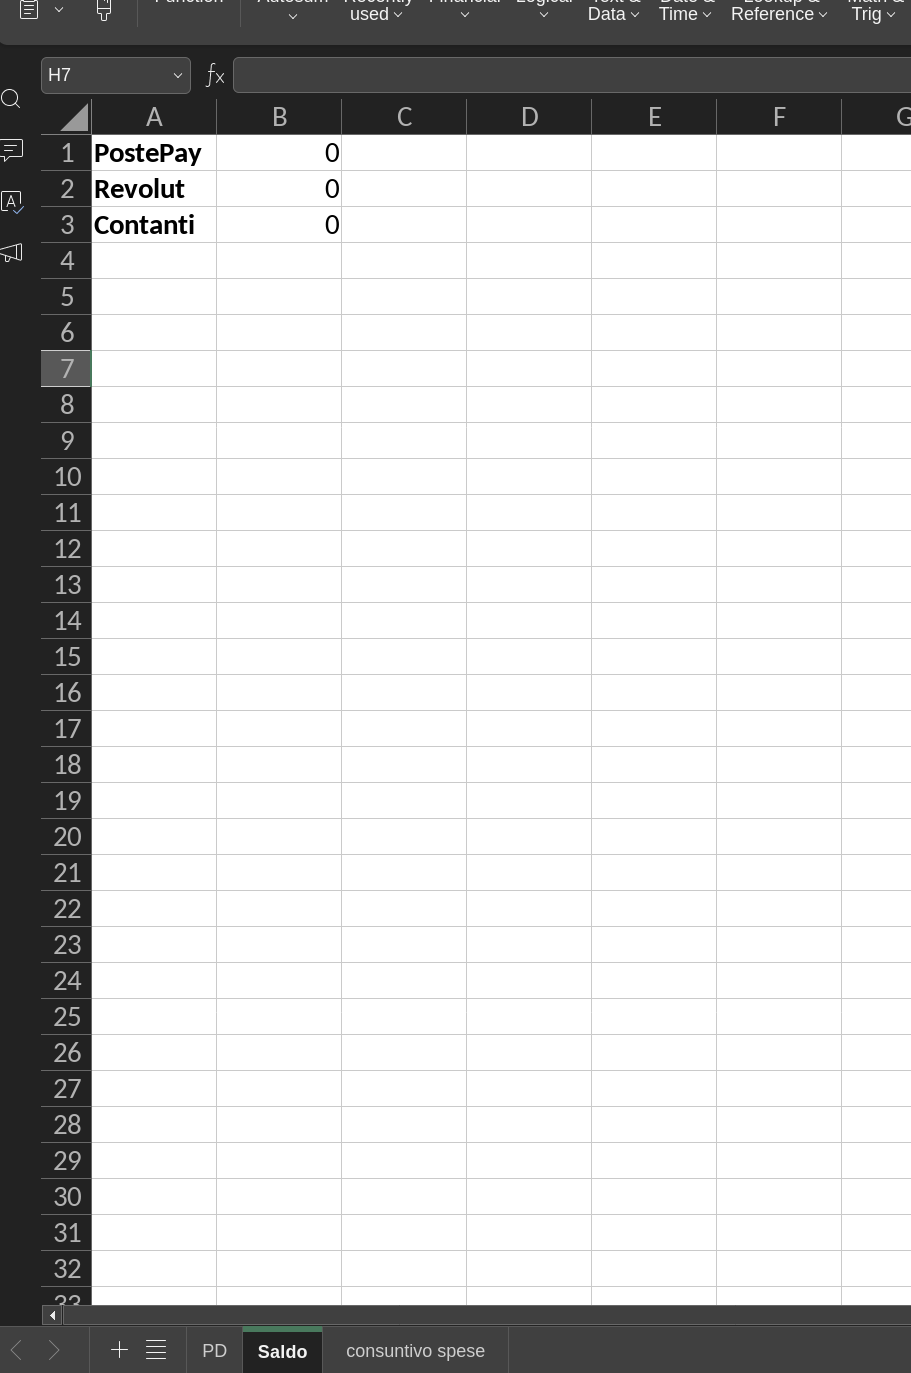
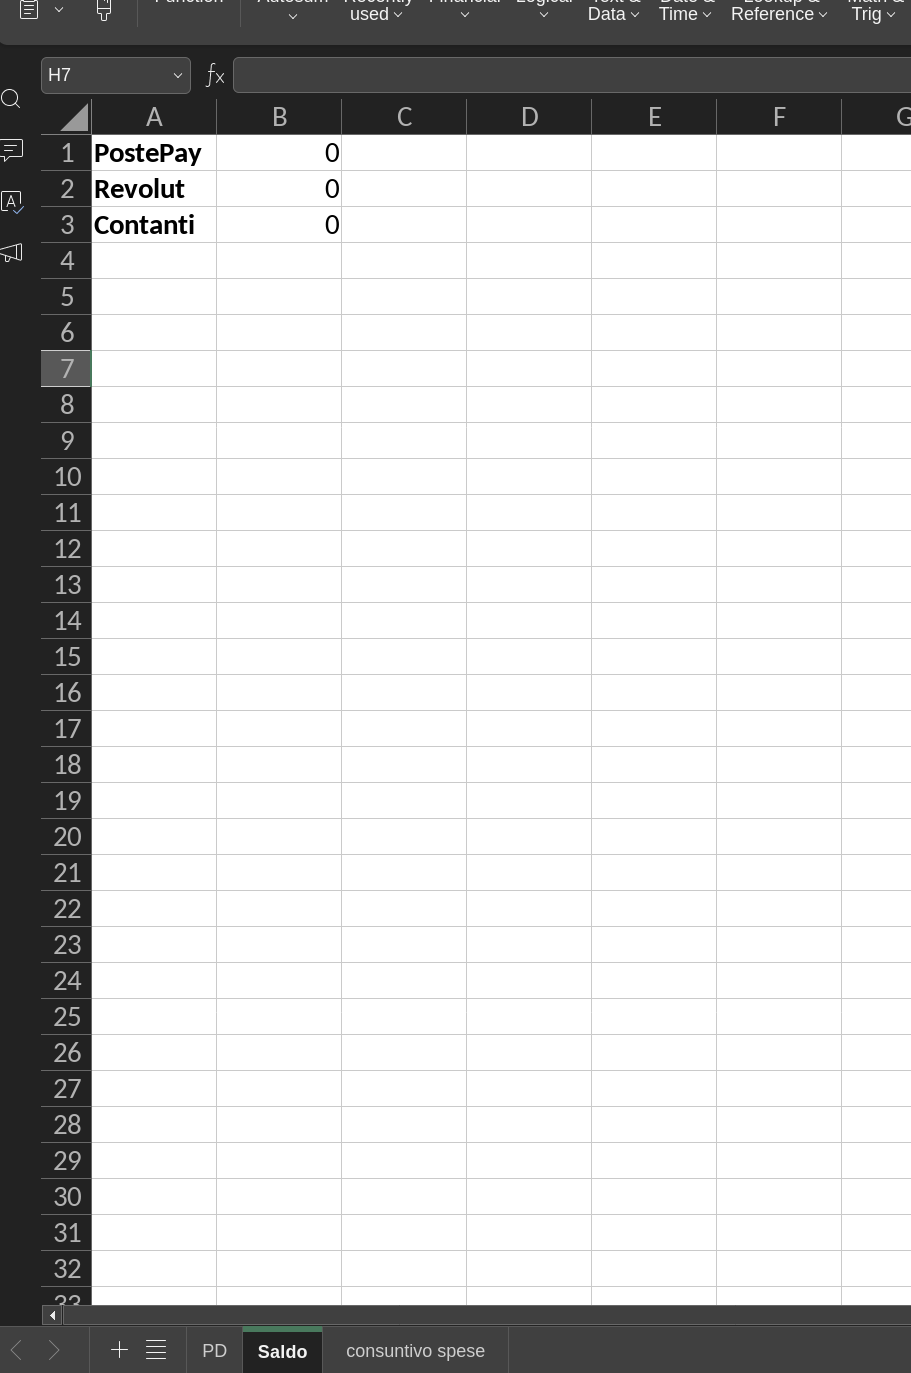
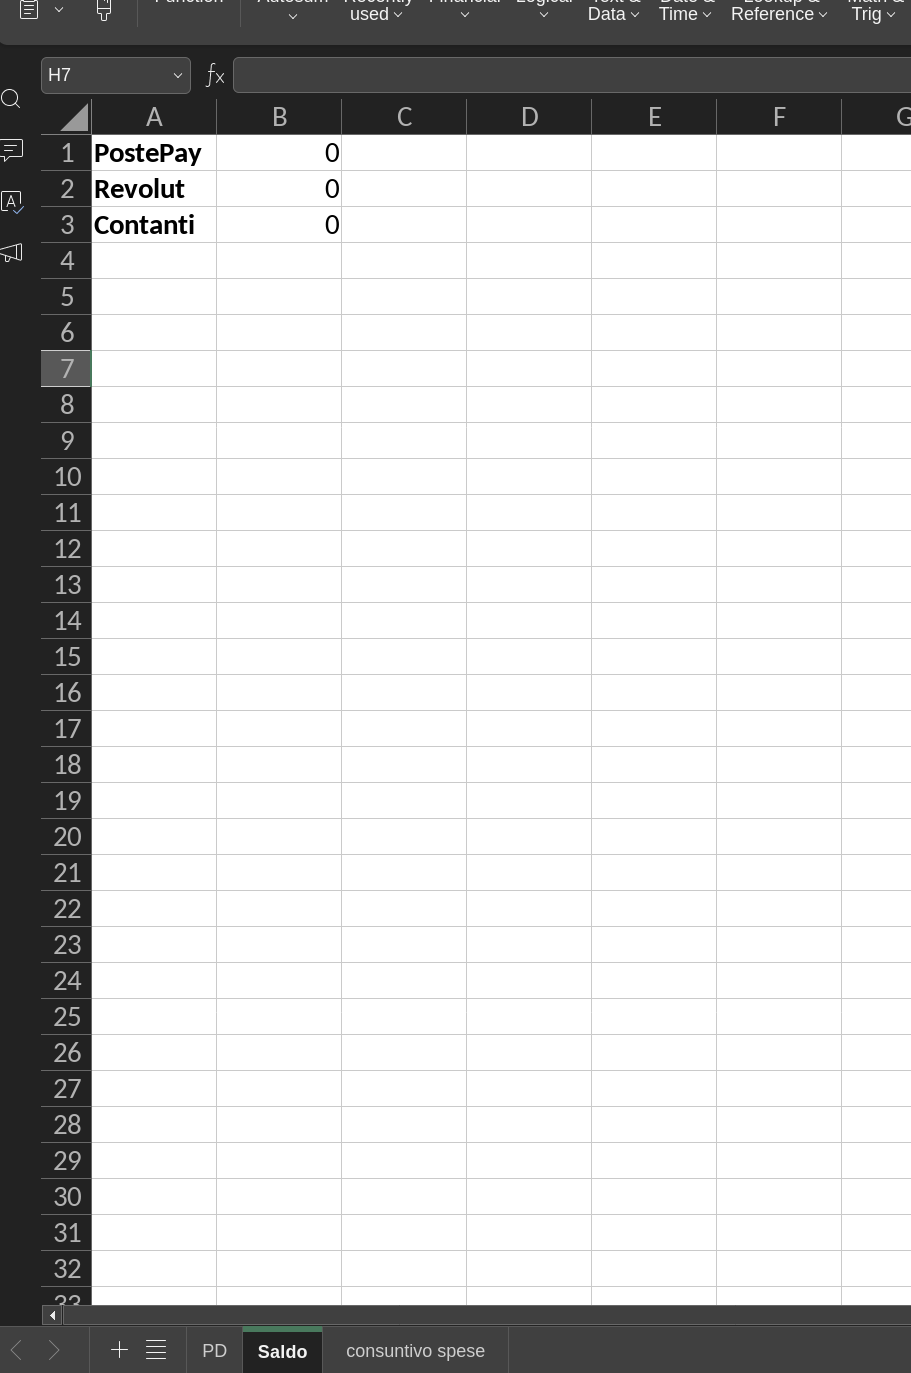

In [ ]:
def sommaMinore(a: AlberoBin) -> bool:
    if a is None:
        return False
    _, ret = verificaSomma(a)
    return ret
def verificaSomma(a: AlberoBin) -> tuple[int, bool]:
    if a is None:
        return (0, False)
    if eFoglia(a):
        return (a.val, False)
    somma1, ret1 = verificaSomma(a.sin)
    somma2, ret2 = verificaSomma(a.des)
    if ret1 or ret2:
        return (0, True)
    return (a.val+somma1+somma2, a.val < somma1+somma2)
def eFoglia(a: AlberoBin) -> bool:
    if a is None or a.sin is not None or a.des is not None:
        return False
    return True

# Esercizio telegram 2

Una funzione `verifica(a: AlberoBin) -> bool` restituisce `True` se i nodi non foglia di `a` hanno almeno uno dei loro figli o discendenti che
ha un valore maggiore del proprio grado di discendenza. Esempio se è il figlio deve essere 1 , se è un nipote deve essere >2 , e cosi via.

In [ ]:
def verifica(a: AlberoBin) -> bool:
    if a is None or eFoglia(a):
        return True
    return (verificaRic(a.sin, 1) or verificaRic(a.des, 1)) and verifica(a.sin) and verifica(a.des)
def verificaRic(a: AlberoBin, h: int) -> bool:
    if a is None:
        return False
    if a.val > h:
        return True
    return verificaRic(a.sin, h+1) or verificaRic(a.des, h+1)

# Esercizio telegram 2

scrivere funzione (con ingresso solo a) che ritorna true se ad un livello tutti i nodi sono
uguali a 0

In [ ]:
def verificaLivRic(a: AlberoBin) -> bool:
    if a is None:
        return False
    zeri: list[bool] = []
    verificaZeri(a, zeri, 0)
    if True in zeri:
        return True
    return False
def verificaZeri(a: AlberoBin, zeri: list[bool], liv: int):
    if a is None:
        return
    if liv == len(zeri):
        zeri.append(a.val == 0)
    elif a.val != 0:
        zeri[liv] = False
    verificaZeri(a.sin, zeri, liv+1)
    verificaZeri(a.des, zeri, liv+1)

def verificaLiv(a: AlberoBin) -> bool:
    if a is None:
        return False
    res: list[list[int]] = []
    coda: list[tuple[int, int]] = [] # (nodo, liv)
    coda.append((a, 0))
    while len(coda) != 0:
        curr, livCurr = coda.pop(0)
        if livCurr == len(res):
            res.append([])
        res[livCurr].append(curr.val)
        if curr.sin is not None:
            coda.append((curr.sin, livCurr + 1))
        if curr.des is not None:
            coda.append((curr.des, livCurr + 1))
    for i in res:
        if tuttiZero(i):
            return True
    return False
def tuttiZero(lista: list[int]) -> bool:
    for i in lista:
        if i != 0:
            return False
    return True

# Esercizio telegram 3

Fare una funzione che ritorna true se esiste almeno un nodo foglia x al livello liv tale che
x.val()+liv == r dove r è il valore contenuto nella radice
E dire la complessità peggiore e migliore della temporale e della spaziale

In [ ]:
def es3(a: AlberoBin):
    if a is None:
        return False
    return es3Ric(a, 0, a.val)
def es3Ric(a: AlberoBin, liv: int, rad: int) -> bool:
    if a is None:
        return False
    if eFoglia(a):
        return a.val + liv == rad
    return es3Ric(a.sin, liv + 1, rad) or es3Ric(a.des, liv + 1, rad)

# Esercizio telegram 4

Fare un algoritmo che ricevuti 2 alberi A e B ritorni `True` se almeno un nodo non foglia dell'albero A è minore del massimo valore dei livelli dispari di B

In [ ]:
def es4(a: AlberoBin, b: AlberoBin) -> bool:
    if a is None or b is None:
        return False
    return nodoMinore(a, maxDisp(b, 0))
def maxDisp(a: AlberoBin, liv: int) -> int:
    if a is None:
        return float('-inf')
    return max(a.val if liv % 2 == 1 else float('-inf'), maxDisp(a.sin, liv+1), maxDisp(a.des, liv+1))
def nodoMinore(a: AlberoBin, x) -> bool:
    if a is None:
        return False
    return (not eFoglia(a) and a.val < x) or nodoMinore(a.sin, x) or nodoMinore(a.des, x)
def eFoglia(a: AlberoBin) -> bool:
    if a is None:
        return False
    return a.sin is None and a.des is None

# Esercizio telegram 5

Fare una funzione che dato un albero come parametro, restituisca la somma delle foglie che si trovano alla profondità minima dell'albero. Dire complessità spaziale/temporale peggiore e migliore

In [ ]:
def sommaFoglie(a: AlberoBin) -> int:
    if a is None:
        return 0
    return foglieLiv(a, profMin(a, 0), 0)
def profMin(a: AlberoBin, liv: int) -> int:
    if a is None:
        return float('inf')
    if eFoglia(a):
        return liv
    return min(profMin(a.sin, liv+1), profMin(a.des, liv+1))
def foglieLiv(a: AlberoBin, liv: int, curr: int) -> int:
    if a is None:
        return 0
    return a.val if eFoglia(a) and liv == curr else foglieLiv(a.sin, liv, curr+1) + foglieLiv(a.des, liv, curr+1)

# Esercizio telegram 6

Dato un albero binario A, e due interi h e k con k>h, scrivere una funzione che restituisca una lista di coppie dove ogni coppia è così formata: il primo elemento sarà il valore dei nodi che si trovano sotto il livello k e il secondo l'occorrenza di tale valore nei livelli prima di h.

In [ ]:
def occorrenze(a: AlberoBin, k: int, h: int):
    if a is None or k <= h:
        raise ValueError
    res: list[tuple[int, int]] = sottoK(a, k, 0)
    riempi(a, h, res, 0)
    return res
def sottoK(a: AlberoBin, k: int, curr: int) -> list[tuple[int, int]]:
    if a is None:
        return []
    return ([(a.val, 0)] if  curr > k else []) + sottoK(a.sin, k, curr + 1) + sottoK(a.des, k, curr + 1)
def riempi(a: AlberoBin, h: int, res: list[tuple[int, int]], curr: int):
    if a is None or curr >= h:
        return
    for i in range(len(res)):
        if res[i][0] == a.val:
            res[i][1] += 1
    riempi(a.sin, h, res, curr + 1)
    riempi(a.des, h, res, curr + 1)

Dato un grafo G , un nodo x ed un intero k , scrivere una funzione che restituisca True se e solo se il nodo x è l'unico tale per cui la somma dei pesi degli archi entranti in quest'ultimo è pari a k.

Si hanno a disposizione i metodi:

- nodes che restituisce i nodi del grafo

- isEdge che dice se c'è un arco tra due nodi

- weight che restituisce il peso dell'arco tra due nodi

In [ ]:
from grafi.grafipesati import grafoP

def pesoEntranti(g: GrafoP, x: int, k: int) -> bool:
    sommax = 0
    for n in nodes(g):
        if isEdge(n, x):
            sommax += weight(n, x)
    if sommax != k:
        return False
    for n1 in nodes(g):
        somma = 0
        if n1 == x:
            continue
        for n2 in nodes(g):
            if n2 == n1:
                continue
            if isEdge(n2, n1):
                somma += weight(n2, n1)
        if somma == k:
            return False
    return True

# Esercizio telegram 7

`public static boolean verifica(AB a, AB b, int k)` Restituisce true se e solo se per ogni nodo foglia x di a esistono almeno k nodi non foglia y nel sotto albero destro di b tali che x.val()==y.val(), supposto k>0.

In [ ]:
def verifica(a: AlberoBin, b: AlberoBin, k: int) -> bool:
    if a is None:
        return True
    return (trova(b.des, a.val) >= k if eFoglia(a) else True) and  verifica(a.sin, b, k) and verifica(a.des, b, k)
def trova(a: AlberoBin, x: int) -> int:
    if a is None:
        return 0
    return (1 if a.val == x and not eFoglia(a) else 0) + trova(a.sin, x) + trova(a.des, x)

# Esercizio telegram 8

dato un albero in input e un intero z, restituisca true se e solo se presi 2 nodi distinti non foglia, a livelli pari vale che x.val *y.val == z

In [ ]:
def es8(a: AlberoBin, z: int):
    liv: list[int] = livPari(a, 0)
    for i in range(len(liv)):
        for j in range(len(liv)):
            if i != j and liv[i]*liv[j] == z:
                return True
    return False
def livPari(a: AlberoBin, curr: int) -> list[int]:
    if a is None:
        return []
    return ([a.val] if not eFoglia(a) and curr % 2 == 0 else []) + livPari(a.sin, curr + 1) + livPari(a.des, curr + 1)

# Prova esame

Scrivere un algoritmo di programmazione dinamica che, dato in ingresso un insieme di valori A e un intero S, deve verificare se esiste un insieme $A' \subseteq A$ tale che la somma dei valori di $A'$ è un multiplo di S

In [ ]:
def esame2(a: list[int], s: int) -> bool:
    n = len(a)
    D = [[False for _ in range(s)] for _ in range(n)]

    for i in range(n):
        for j in range(s):
            if i == 0:
                # riga base: verifico se con solo a{0} ho resto 0 -> l'unico sottoinsieme possibile è {a[0]}
                D[i][j] = (a[i] % s == j)
            else:
                # preso da solo || non preso || preso con i precedenti (verifico se tra i risultati precedenti c'è un sottoinsieme che dà come resto j-a[i] così che sommandoci a[i] mi dà come resto esattamente j
                D[i][j] = a[i] % s == j or D[i-1][j] or D[i-1][(j - a[i]) % s]
    return D[n-1][0]